In [8]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving data_core.csv to data_core (1).csv


In [9]:
df = pd.read_csv("data_core.csv.csv")

print("Dataset shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data_core.csv.csv'

In [10]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Column names:


NameError: name 'df' is not defined

In [ ]:
#define inputs anf targets
# Input features
input_features = [
    "Temparature",
    "Humidity",
    "Moisture",
    "Soil Type",
    "Crop Type"
]

# Nutrient values
nutrient_features = [
    "Nitrogen",
    "Potassium",
    "Phosphorous"
]

print("Input Features:")
print(input_features)

print("\nNutrient Features:")
print(nutrient_features)

In [ ]:
print("Nitrogen values:")
print(df["Nitrogen"].describe())

print("\nPhosphorous values:")
print(df["Phosphorous"].describe())

print("\nPotassium values:")
print(df["Potassium"].describe())

In [ ]:
print("Nitrogen value counts:")
print(df["Nitrogen"].value_counts().sort_index())

print("\nPhosphorous value counts:")
print(df["Phosphorous"].value_counts().sort_index())

print("\nPotassium value counts:")
print(df["Potassium"].value_counts().sort_index())

In [ ]:
print(pd.crosstab(df["Fertilizer Name"], df["Nitrogen"]))
print("\n--- Phosphorous ---")
print(pd.crosstab(df["Fertilizer Name"], df["Phosphorous"]))
print("\n--- Potassium ---")
print(pd.crosstab(df["Fertilizer Name"], df["Potassium"]))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(df["Nitrogen"], bins=20)
plt.xlabel("Nitrogen")
plt.ylabel("Number of samples")
plt.title("Nitrogen Distribution")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(df["Phosphorous"], bins=20)
plt.xlabel("Phosphorous")
plt.ylabel("Number of samples")
plt.title("Phosphorous Distribution")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(df["Potassium"], bins=20)
plt.xlabel("Potassium")
plt.ylabel("Number of samples")
plt.title("Potassium Distribution")
plt.show()

In [ ]:
#nutrient deficiency targets
# Define deficiency thresholds using the 25th percentile
N_threshold = df["Nitrogen"].quantile(0.25)
P_threshold = df["Phosphorous"].quantile(0.25)
K_threshold = df["Potassium"].quantile(0.25)

print("Nitrogen deficiency threshold:", N_threshold)
print("Phosphorous deficiency threshold:", P_threshold)
print("Potassium deficiency threshold:", K_threshold)

In [ ]:
df["N_deficiency"] = (df["Nitrogen"] <= N_threshold).astype(int)
df["P_deficiency"] = (df["Phosphorous"] <= P_threshold).astype(int)
df["K_deficiency"] = (df["Potassium"] <= K_threshold).astype(int)

print(df[["Nitrogen", "N_deficiency",
          "Phosphorous", "P_deficiency",
          "Potassium", "K_deficiency"]].head(10))

In [ ]:
#Check whether our deficiency targets are balanced
print("Nitrogen deficiency:")
print(df["N_deficiency"].value_counts())
print(df["N_deficiency"].value_counts(normalize=True) * 100)

print("\nPhosphorous deficiency:")
print(df["P_deficiency"].value_counts())
print(df["P_deficiency"].value_counts(normalize=True) * 100)

print("\nPotassium deficiency:")
print(df["K_deficiency"].value_counts())
print(df["K_deficiency"].value_counts(normalize=True) * 100)

In [ ]:
# Input features
X = df[
    [
        "Temparature",
        "Humidity",
        "Moisture",
        "Soil Type",
        "Crop Type"
    ]
]

# Targets
y_N = df["N_deficiency"]
y_P = df["P_deficiency"]
y_K = df["K_deficiency"]

print("Input features:")
print(X.head())

print("\nInput shape:", X.shape)

print("\nTargets:")
print("Nitrogen:", y_N.shape)
print("Phosphorous:", y_P.shape)
print("Potassium:", y_K.shape)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Numerical and categorical features
numeric_features = [
    "Temparature",
    "Humidity",
    "Moisture"
]

categorical_features = [
    "Soil Type",
    "Crop Type"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully!")

In [ ]:
#encode the features
# Transform the input features into numerical form
X_encoded = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

In [ ]:
#split data into training and testing sets
from sklearn.model_selection import train_test_split

# Nitrogen deficiency
X_train_N, X_test_N, y_train_N, y_test_N = train_test_split(
    X_encoded,
    y_N,
    test_size=0.20,
    random_state=42,
    stratify=y_N
)

# Phosphorous deficiency
X_train_P, X_test_P, y_train_P, y_test_P = train_test_split(
    X_encoded,
    y_P,
    test_size=0.20,
    random_state=42,
    stratify=y_P
)

# Potassium deficiency
X_train_K, X_test_K, y_train_K, y_test_K = train_test_split(
    X_encoded,
    y_K,
    test_size=0.20,
    random_state=42,
    stratify=y_K
)

print("Nitrogen:", X_train_N.shape, X_test_N.shape)
print("Phosphorous:", X_train_P.shape, X_test_P.shape)
print("Potassium:", X_train_K.shape, X_test_K.shape)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Create models
model_N = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_P = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_K = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the models
model_N.fit(X_train_N, y_train_N)
model_P.fit(X_train_P, y_train_P)
model_K.fit(X_train_K, y_train_K)

print("Nitrogen model trained successfully!")
print("Phosphorous model trained successfully!")
print("Potassium model trained successfully!")

In [ ]:
# Generate predictions for each nutrient

y_pred_N = model_N.predict(X_test_N)
y_pred_P = model_P.predict(X_test_P)
y_pred_K = model_K.predict(X_test_K)

print("Nitrogen predictions generated!")
print("Phosphorous predictions generated!")
print("Potassium predictions generated!")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Nitrogen
print("===== Nitrogen Deficiency =====")
print("Accuracy :", accuracy_score(y_test_N, y_pred_N))
print("Precision:", precision_score(y_test_N, y_pred_N))
print("Recall   :", recall_score(y_test_N, y_pred_N))
print("F1-Score :", f1_score(y_test_N, y_pred_N))

# Phosphorous
print("\n===== Phosphorous Deficiency =====")
print("Accuracy :", accuracy_score(y_test_P, y_pred_P))
print("Precision:", precision_score(y_test_P, y_pred_P))
print("Recall   :", recall_score(y_test_P, y_pred_P))
print("F1-Score :", f1_score(y_test_P, y_pred_P))

# Potassium
print("\n===== Potassium Deficiency =====")
print("Accuracy :", accuracy_score(y_test_K, y_pred_K))
print("Precision:", precision_score(y_test_K, y_pred_K))
print("Recall   :", recall_score(y_test_K, y_pred_K))
print("F1-Score :", f1_score(y_test_K, y_pred_K))

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrices
cm_N = confusion_matrix(y_test_N, y_pred_N)
cm_P = confusion_matrix(y_test_P, y_pred_P)
cm_K = confusion_matrix(y_test_K, y_pred_K)

# Nitrogen
plt.figure(figsize=(5, 4))
sns.heatmap(cm_N, annot=True, fmt="d", cmap="Blues")
plt.title("Nitrogen Deficiency - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Phosphorous
plt.figure(figsize=(5, 4))
sns.heatmap(cm_P, annot=True, fmt="d", cmap="Blues")
plt.title("Phosphorous Deficiency - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Potassium
plt.figure(figsize=(5, 4))
sns.heatmap(cm_K, annot=True, fmt="d", cmap="Blues")
plt.title("Potassium Deficiency - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4]
}

grid_N = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_N.fit(X_train_N, y_train_N)

print("Best Nitrogen parameters:")
print(grid_N.best_params_)

print("Best Nitrogen F1-score:")
print(grid_N.best_score_)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4]
}

grid_N = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_N.fit(X_train_N, y_train_N)

print("Best Nitrogen parameters:")
print(grid_N.best_params_)

print("Best Nitrogen F1-score:")
print(grid_N.best_score_)

In [ ]:
# Hyperparameter tuning for Phosphorous

grid_P = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_P.fit(X_train_P, y_train_P)

print("Best Phosphorous parameters:")
print(grid_P.best_params_)

print("Best Phosphorous F1-score:")
print(grid_P.best_score_)

In [ ]:
# Hyperparameter tuning for Potassium

grid_K = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_K.fit(X_train_K, y_train_K)

print("Best Potassium parameters:")
print(grid_K.best_params_)

print("Best Potassium F1-score:")
print(grid_K.best_score_)

In [ ]:
# Select the best tuned models

best_model_N = grid_N.best_estimator_
best_model_P = grid_P.best_estimator_
best_model_K = grid_K.best_estimator_

print("Best Nitrogen model selected!")
print("Best Phosphorous model selected!")
print("Best Potassium model selected!")

In [ ]:
#generate predictions
# Predictions from the tuned/best models

y_pred_N_best = best_model_N.predict(X_test_N)
y_pred_P_best = best_model_P.predict(X_test_P)
y_pred_K_best = best_model_K.predict(X_test_K)

print("Tuned Nitrogen predictions generated!")
print("Tuned Phosphorous predictions generated!")
print("Tuned Potassium predictions generated!")

In [ ]:
# Evaluate tuned models

print("===== Tuned Nitrogen Model =====")
print("Accuracy :", accuracy_score(y_test_N, y_pred_N_best))
print("Precision:", precision_score(y_test_N, y_pred_N_best))
print("Recall   :", recall_score(y_test_N, y_pred_N_best))
print("F1-Score :", f1_score(y_test_N, y_pred_N_best))

print("\n===== Tuned Phosphorous Model =====")
print("Accuracy :", accuracy_score(y_test_P, y_pred_P_best))
print("Precision:", precision_score(y_test_P, y_pred_P_best))
print("Recall   :", recall_score(y_test_P, y_pred_P_best))
print("F1-Score :", f1_score(y_test_P, y_pred_P_best))

print("\n===== Tuned Potassium Model =====")
print("Accuracy :", accuracy_score(y_test_K, y_pred_K_best))
print("Precision:", precision_score(y_test_K, y_pred_K_best))
print("Recall   :", recall_score(y_test_K, y_pred_K_best))
print("F1-Score :", f1_score(y_test_K, y_pred_K_best))

In [ ]:
import joblib

# Save the trained models
joblib.dump(best_model_N, "/content/best_nitrogen_model.pkl")
joblib.dump(best_model_P, "/content/best_phosphorous_model.pkl")
joblib.dump(best_model_K, "/content/best_potassium_model.pkl")

# Save the preprocessing object too
joblib.dump(preprocessor, "/content/soil_preprocessor.pkl")

print("Nitrogen model saved!")
print("Phosphorous model saved!")
print("Potassium model saved!")
print("Preprocessor saved!")

In [ ]:
import joblib

# Load the saved models
loaded_N = joblib.load("/content/best_nitrogen_model.pkl")
loaded_P = joblib.load("/content/best_phosphorous_model.pkl")
loaded_K = joblib.load("/content/best_potassium_model.pkl")
loaded_preprocessor = joblib.load("/content/soil_preprocessor.pkl")

print("Nitrogen model loaded successfully!")
print("Phosphorous model loaded successfully!")
print("Potassium model loaded successfully!")
print("Preprocessor loaded successfully!")

In [ ]:
!pip install shap -q

import shap
import numpy as np
import pandas as pd

print("SHAP installed successfully!")
print("SHAP version:", shap.__version__)

In [ ]:
# Convert sparse matrix to a normal numeric array for SHAP

X_test_N_shap = X_test_N.toarray().astype("float64")

print("SHAP input dtype:", X_test_N_shap.dtype)
print("SHAP input shape:", X_test_N_shap.shape)

In [ ]:
# Create SHAP explainer
explainer_N = shap.TreeExplainer(best_model_N)

# Generate SHAP values
shap_values_N = explainer_N.shap_values(X_test_N_shap)

print("SHAP values generated successfully!")
print("SHAP values shape:", np.array(shap_values_N).shape)

In [ ]:
# SHAP feature importance for Nitrogen deficiency

shap.summary_plot(
    shap_values_N,
    X_test_N_shap,
    feature_names=preprocessor.get_feature_names_out()
)

In [ ]:
# Convert test data for SHAP
X_test_P_shap = X_test_P.toarray().astype("float64")

# Create SHAP explainer
explainer_P = shap.TreeExplainer(best_model_P)

# Generate SHAP values
shap_values_P = explainer_P.shap_values(X_test_P_shap)

print("SHAP values generated for Phosphorous!")
print("SHAP values shape:", np.array(shap_values_P).shape)

In [ ]:
# Convert test data for SHAP
X_test_K_shap = X_test_K.toarray().astype("float64")

# Create SHAP explainer
explainer_K = shap.TreeExplainer(best_model_K)

# Generate SHAP values
shap_values_K = explainer_K.shap_values(X_test_K_shap)

print("SHAP values generated for Potassium!")
print("SHAP values shape:", np.array(shap_values_K).shape)

In [ ]:
shap.summary_plot(
    shap_values_K,
    X_test_K_shap,
    feature_names=preprocessor.get_feature_names_out()
)

In [ ]:
import numpy as np
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

# Calculate mean absolute SHAP importance
importance_N = np.mean(np.abs(shap_values_N), axis=0)
importance_P = np.mean(np.abs(shap_values_P), axis=0)
importance_K = np.mean(np.abs(shap_values_K), axis=0)

# Create comparison table
shap_comparison = pd.DataFrame({
    "Feature": feature_names,
    "Nitrogen": importance_N,
    "Phosphorous": importance_P,
    "Potassium": importance_K
})

# Overall importance
shap_comparison["Overall_Importance"] = (
    importance_N + importance_P + importance_K
) / 3

# Sort by overall importance
shap_comparison = shap_comparison.sort_values(
    "Overall_Importance",
    ascending=False
)

print(shap_comparison.head(15))

In [ ]:
import os

print(os.listdir("/content"))

In [ ]:
import os

print(os.path.exists("/content/soil_resnet50_model.keras"))
print(os.listdir("/content"))

In [ ]:
# Save SHAP feature importance results

shap_comparison.to_csv(
    "/content/SHAP_feature_importance_comparison.csv",
    index=False
)

print("SHAP feature-importance results saved successfully!")

In [ ]:
# Create final nutrient deficiency prediction summary

prediction_summary = pd.DataFrame({
    "Actual_N_Deficiency": y_test_N.values,
    "Predicted_N_Deficiency": y_pred_N_best,
    "Actual_P_Deficiency": y_test_P.values,
    "Predicted_P_Deficiency": y_pred_P_best,
    "Actual_K_Deficiency": y_test_K.values,
    "Predicted_K_Deficiency": y_pred_K_best
})

print("Final prediction summary created!")
print(prediction_summary.head(10))

In [ ]:
def predict_nutrient_deficiency(temperature, humidity, moisture,
                                soil_type, crop_type):

    new_data = pd.DataFrame({
        "Temparature": [temperature],
        "Humidity": [humidity],
        "Moisture": [moisture],
        "Soil Type": [soil_type],
        "Crop Type": [crop_type]
    })

    # Apply the same preprocessing used during training
    new_data_encoded = loaded_preprocessor.transform(new_data)

    # Predictions
    n_prediction = loaded_N.predict(new_data_encoded)[0]
    p_prediction = loaded_P.predict(new_data_encoded)[0]
    k_prediction = loaded_K.predict(new_data_encoded)[0]

    return n_prediction, p_prediction, k_prediction


print("Hybrid prediction function created successfully!")

In [ ]:
# Example soil sample

N_pred, P_pred, K_pred = predict_nutrient_deficiency(
    temperature=26,
    humidity=52,
    moisture=38,
    soil_type="Sandy",
    crop_type="Maize"
)

print("Nitrogen deficiency:", "Yes" if N_pred == 1 else "No")
print("Phosphorous deficiency:", "Yes" if P_pred == 1 else "No")
print("Potassium deficiency:", "Yes" if K_pred == 1 else "No")

In [ ]:
# Get prediction probabilities for the example soil sample

N_prob = loaded_N.predict_proba(
    loaded_preprocessor.transform(pd.DataFrame({
        "Temparature": [26],
        "Humidity": [52],
        "Moisture": [38],
        "Soil Type": ["Sandy"],
        "Crop Type": ["Maize"]
    }))
)[0]

P_prob = loaded_P.predict_proba(
    loaded_preprocessor.transform(pd.DataFrame({
        "Temparature": [26],
        "Humidity": [52],
        "Moisture": [38],
        "Soil Type": ["Sandy"],
        "Crop Type": ["Maize"]
    }))
)[0]

K_prob = loaded_K.predict_proba(
    loaded_preprocessor.transform(pd.DataFrame({
        "Temparature": [26],
        "Humidity": [52],
        "Moisture": [38],
        "Soil Type": ["Sandy"],
        "Crop Type": ["Maize"]
    }))
)[0]

print("Nitrogen probabilities:", N_prob)
print("Phosphorous probabilities:", P_prob)
print("Potassium probabilities:", K_prob)

In [ ]:
def hybrid_nutrient_assessment(N_prob, P_prob, K_prob):

    # Probability of deficiency
    N_conf = N_prob[1]
    P_conf = P_prob[1]
    K_conf = K_prob[1]

    deficiencies = []

    if N_conf >= 0.5:
        deficiencies.append("Nitrogen")

    if P_conf >= 0.5:
        deficiencies.append("Phosphorous")

    if K_conf >= 0.5:
        deficiencies.append("Potassium")

    # Overall deficiency confidence
    overall_confidence = (N_conf + P_conf + K_conf) / 3

    if len(deficiencies) == 0:
        assessment = "No major nutrient deficiency predicted"
    else:
        assessment = "Deficiency detected: " + ", ".join(deficiencies)

    return assessment, overall_confidence


assessment, overall_confidence = hybrid_nutrient_assessment(
    N_prob, P_prob, K_prob
)

print("Overall Soil Assessment:")
print(assessment)
print(f"Overall deficiency confidence: {overall_confidence * 100:.2f}%")

In [11]:
# Prepare the sample soil data
sample_data = pd.DataFrame({
    "Temparature": [26],
    "Humidity": [52],
    "Moisture": [38],
    "Soil Type": ["Sandy"],
    "Crop Type": ["Maize"]
})

# Preprocess the sample
sample_encoded = loaded_preprocessor.transform(sample_data)

# Get probabilities
N_prob = loaded_N.predict_proba(sample_encoded)[0]
P_prob = loaded_P.predict_proba(sample_encoded)[0]
K_prob = loaded_K.predict_proba(sample_encoded)[0]

print("Nitrogen probabilities:", N_prob)
print("Phosphorous probabilities:", P_prob)
print("Potassium probabilities:", K_prob)

NameError: name 'loaded_preprocessor' is not defined

In [12]:
print("Colab runtime is working!")

Colab runtime is working!


In [13]:
import os

print(os.listdir("/content"))

['.config', 'data_core (1).csv', 'data_core.csv', 'sample_data']


In [14]:
import pandas as pd

df = pd.read_csv("/content/data_core.csv")

print("Dataset shape:", df.shape)
print(df.columns.tolist())
df.head()

Dataset shape: (8000, 9)
['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea


In [15]:
# Dataset-based deficiency thresholds
N_threshold = df["Nitrogen"].quantile(0.25)
P_threshold = df["Phosphorous"].quantile(0.25)
K_threshold = df["Potassium"].quantile(0.25)

# Create deficiency labels
df["N_deficiency"] = (df["Nitrogen"] <= N_threshold).astype(int)
df["P_deficiency"] = (df["Phosphorous"] <= P_threshold).astype(int)
df["K_deficiency"] = (df["Potassium"] <= K_threshold).astype(int)

print("Nitrogen threshold:", N_threshold)
print("Phosphorous threshold:", P_threshold)
print("Potassium threshold:", K_threshold)

print("\nDeficiency targets recreated successfully!")

Nitrogen threshold: 9.0
Phosphorous threshold: 8.0
Potassium threshold: 0.0

Deficiency targets recreated successfully!


In [17]:
# Input features for nutrient-deficiency prediction

X = df[
    [
        "Temparature",
        "Humidity",
        "Moisture",
        "Soil Type",
        "Crop Type"
    ]
]

y_N = df["N_deficiency"]
y_P = df["P_deficiency"]
y_K = df["K_deficiency"]

print("Input features:", X.columns.tolist())
print("Number of samples:", len(X))

Input features: ['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type']
Number of samples: 8000


In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = [
    "Temparature",
    "Humidity",
    "Moisture"
]

categorical_features = [
    "Soil Type",
    "Crop Type"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_encoded = preprocessor.fit_transform(X)

print("Preprocessing completed!")
print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

Preprocessing completed!
Original shape: (8000, 5)
Encoded shape: (8000, 19)


In [19]:
from sklearn.model_selection import train_test_split

# Nitrogen
X_train_N, X_test_N, y_train_N, y_test_N = train_test_split(
    X_encoded, y_N,
    test_size=0.20,
    random_state=42,
    stratify=y_N
)

# Phosphorous
X_train_P, X_test_P, y_train_P, y_test_P = train_test_split(
    X_encoded, y_P,
    test_size=0.20,
    random_state=42,
    stratify=y_P
)

# Potassium
X_train_K, X_test_K, y_train_K, y_test_K = train_test_split(
    X_encoded, y_K,
    test_size=0.20,
    random_state=42,
    stratify=y_K
)

print("Nitrogen:", X_train_N.shape, X_test_N.shape)
print("Phosphorous:", X_train_P.shape, X_test_P.shape)
print("Potassium:", X_train_K.shape, X_test_K.shape)

Nitrogen: (6400, 19) (1600, 19)
Phosphorous: (6400, 19) (1600, 19)
Potassium: (6400, 19) (1600, 19)


In [20]:
from sklearn.ensemble import GradientBoostingClassifier

# Create models
model_N = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_P = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_K = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train
model_N.fit(X_train_N, y_train_N)
model_P.fit(X_train_P, y_train_P)
model_K.fit(X_train_K, y_train_K)

print("Nitrogen model trained successfully!")
print("Phosphorous model trained successfully!")
print("Potassium model trained successfully!")

Nitrogen model trained successfully!
Phosphorous model trained successfully!
Potassium model trained successfully!


In [21]:
y_pred_N = model_N.predict(X_test_N)
y_pred_P = model_P.predict(X_test_P)
y_pred_K = model_K.predict(X_test_K)

print("Nitrogen predictions generated!")
print("Phosphorous predictions generated!")
print("Potassium predictions generated!")

Nitrogen predictions generated!
Phosphorous predictions generated!
Potassium predictions generated!


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("===== Nitrogen Deficiency =====")
print("Accuracy :", accuracy_score(y_test_N, y_pred_N))
print("Precision:", precision_score(y_test_N, y_pred_N))
print("Recall   :", recall_score(y_test_N, y_pred_N))
print("F1-Score :", f1_score(y_test_N, y_pred_N))

print("\n===== Phosphorous Deficiency =====")
print("Accuracy :", accuracy_score(y_test_P, y_pred_P))
print("Precision:", precision_score(y_test_P, y_pred_P))
print("Recall   :", recall_score(y_test_P, y_pred_P))
print("F1-Score :", f1_score(y_test_P, y_pred_P))

print("\n===== Potassium Deficiency =====")
print("Accuracy :", accuracy_score(y_test_K, y_pred_K))
print("Precision:", precision_score(y_test_K, y_pred_K))
print("Recall   :", recall_score(y_test_K, y_pred_K))
print("F1-Score :", f1_score(y_test_K, y_pred_K))

===== Nitrogen Deficiency =====
Accuracy : 0.744375
Precision: 0.45454545454545453
Recall   : 0.012254901960784314
F1-Score : 0.02386634844868735

===== Phosphorous Deficiency =====
Accuracy : 0.74125
Precision: 0.64
Recall   : 0.03800475059382423
F1-Score : 0.07174887892376682

===== Potassium Deficiency =====
Accuracy : 0.574375
Precision: 0.5379310344827586
Recall   : 0.11271676300578035
F1-Score : 0.1863799283154122


In [23]:
#chk imbalance
print("Nitrogen:")
print(y_N.value_counts())

print("\nPhosphorous:")
print(y_P.value_counts())

print("\nPotassium:")
print(y_K.value_counts())

Nitrogen:
N_deficiency
0    5961
1    2039
Name: count, dtype: int64

Phosphorous:
P_deficiency
0    5894
1    2106
Name: count, dtype: int64

Potassium:
K_deficiency
0    4540
1    3460
Name: count, dtype: int64


In [24]:
# Check average numeric feature values for deficient vs non-deficient samples

print("===== Nitrogen deficiency =====")
print(df.groupby("N_deficiency")[["Temparature", "Humidity", "Moisture"]].mean())

print("\n===== Phosphorous deficiency =====")
print(df.groupby("P_deficiency")[["Temparature", "Humidity", "Moisture"]].mean())

print("\n===== Potassium deficiency =====")
print(df.groupby("K_deficiency")[["Temparature", "Humidity", "Moisture"]].mean())

===== Nitrogen deficiency =====
              Temparature   Humidity   Moisture
N_deficiency                                   
0               30.270342  58.995969  43.047732
1               30.539308  59.838588  45.139465

===== Phosphorous deficiency =====
              Temparature   Humidity   Moisture
P_deficiency                                   
0               30.466992  59.469367  43.770215
1               29.980394  58.486895  43.050926

===== Potassium deficiency =====
              Temparature   Humidity   Moisture
K_deficiency                                   
0               30.397936  59.312368  43.910240
1               30.261425  59.077370  43.148673


In [25]:
print("===== Nitrogen deficiency by Soil Type =====")
print(pd.crosstab(df["Soil Type"], df["N_deficiency"], normalize="index"))

print("\n===== Phosphorous deficiency by Soil Type =====")
print(pd.crosstab(df["Soil Type"], df["P_deficiency"], normalize="index"))

print("\n===== Potassium deficiency by Soil Type =====")
print(pd.crosstab(df["Soil Type"], df["K_deficiency"], normalize="index"))

===== Nitrogen deficiency by Soil Type =====
N_deficiency         0         1
Soil Type                       
Black         0.727836  0.272164
Clayey        0.742452  0.257548
Loamy         0.751572  0.248428
Red           0.759097  0.240903
Sandy         0.744937  0.255063

===== Phosphorous deficiency by Soil Type =====
P_deficiency         0         1
Soil Type                       
Black         0.742715  0.257285
Clayey        0.728281  0.271719
Loamy         0.727673  0.272327
Red           0.740903  0.259097
Sandy         0.744304  0.255696

===== Potassium deficiency by Soil Type =====
K_deficiency         0         1
Soil Type                       
Black         0.569126  0.430874
Clayey        0.570548  0.429452
Loamy         0.574214  0.425786
Red           0.564617  0.435383
Sandy         0.558861  0.441139


In [26]:
print("===== Nitrogen deficiency by Crop Type =====")
print(pd.crosstab(df["Crop Type"], df["N_deficiency"], normalize="index"))

print("\n===== Phosphorous deficiency by Crop Type =====")
print(pd.crosstab(df["Crop Type"], df["P_deficiency"], normalize="index"))

print("\n===== Potassium deficiency by Crop Type =====")
print(pd.crosstab(df["Crop Type"], df["K_deficiency"], normalize="index"))

===== Nitrogen deficiency by Crop Type =====
N_deficiency         0         1
Crop Type                       
Barley        0.763869  0.236131
Cotton        0.735457  0.264543
Ground Nuts   0.726776  0.273224
Maize         0.762284  0.237716
Millets       0.767409  0.232591
Oil seeds     0.738397  0.261603
Paddy         0.729462  0.270538
Pulses        0.732143  0.267857
Sugarcane     0.760157  0.239843
Tobacco       0.747559  0.252441
Wheat         0.732262  0.267738

===== Phosphorous deficiency by Crop Type =====
P_deficiency         0         1
Crop Type                       
Barley        0.761024  0.238976
Cotton        0.757618  0.242382
Ground Nuts   0.741803  0.258197
Maize         0.717131  0.282869
Millets       0.715877  0.284123
Oil seeds     0.722925  0.277075
Paddy         0.736544  0.263456
Pulses        0.747253  0.252747
Sugarcane     0.726081  0.273919
Tobacco       0.732218  0.267782
Wheat         0.746988  0.253012

===== Potassium deficiency by Crop Type =====
K

So our current conclusion is:

N deficiency: weak relationship with the available input features.
P deficiency: weak-to-moderate relationship.
K deficiency: somewhat stronger relationship, but still not highly separated.
This explains why the original Gradient Boosting model had very low recall/F1, especially for N and P.

We should now try a stronger model rather than changing the labels again

In [27]:
# Install XGBoost
!pip install -q xgboost

In [28]:
from xgboost import XGBClassifier

# Nitrogen model
xgb_N = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Phosphorous model
xgb_P = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Potassium model
xgb_K = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb_N.fit(X_train_N, y_train_N)
xgb_P.fit(X_train_P, y_train_P)
xgb_K.fit(X_train_K, y_train_K)

print("All three XGBoost models trained successfully!")

All three XGBoost models trained successfully!


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
pred_N_xgb = xgb_N.predict(X_test_N)
pred_P_xgb = xgb_P.predict(X_test_P)
pred_K_xgb = xgb_K.predict(X_test_K)

# Evaluation function
def evaluate_model(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1-Score :", f1_score(y_true, y_pred, zero_division=0))

# Evaluate
evaluate_model("XGBoost - Nitrogen Deficiency", y_test_N, pred_N_xgb)
evaluate_model("XGBoost - Phosphorous Deficiency", y_test_P, pred_P_xgb)
evaluate_model("XGBoost - Potassium Deficiency", y_test_K, pred_K_xgb)


===== XGBoost - Nitrogen Deficiency =====
Accuracy : 0.73875
Precision: 0.3076923076923077
Recall   : 0.0196078431372549
F1-Score : 0.03686635944700461

===== XGBoost - Phosphorous Deficiency =====
Accuracy : 0.743125
Precision: 0.5862068965517241
Recall   : 0.08076009501187649
F1-Score : 0.1419624217118998

===== XGBoost - Potassium Deficiency =====
Accuracy : 0.559375
Precision: 0.4809384164222874
Recall   : 0.23699421965317918
F1-Score : 0.31752178121974833


In [31]:
# Gradient Boosting predictions
pred_N = model_N.predict(X_test_N)
pred_P = model_P.predict(X_test_P)
pred_K = model_K.predict(X_test_K)

print("Gradient Boosting predictions recreated successfully!")

Gradient Boosting predictions recreated successfully!


In [32]:
print("===== MODEL COMPARISON =====")

comparison = pd.DataFrame({
    "Nutrient": ["Nitrogen", "Phosphorous", "Potassium"],

    "GB Accuracy": [
        accuracy_score(y_test_N, pred_N),
        accuracy_score(y_test_P, pred_P),
        accuracy_score(y_test_K, pred_K)
    ],

    "XGB Accuracy": [
        accuracy_score(y_test_N, pred_N_xgb),
        accuracy_score(y_test_P, pred_P_xgb),
        accuracy_score(y_test_K, pred_K_xgb)
    ],

    "GB F1": [
        f1_score(y_test_N, pred_N, zero_division=0),
        f1_score(y_test_P, pred_P, zero_division=0),
        f1_score(y_test_K, pred_K, zero_division=0)
    ],

    "XGB F1": [
        f1_score(y_test_N, pred_N_xgb, zero_division=0),
        f1_score(y_test_P, pred_P_xgb, zero_division=0),
        f1_score(y_test_K, pred_K_xgb, zero_division=0)
    ]
})

print(comparison)

===== MODEL COMPARISON =====
      Nutrient  GB Accuracy  XGB Accuracy     GB F1    XGB F1
0     Nitrogen     0.744375      0.738750  0.023866  0.036866
1  Phosphorous     0.741250      0.743125  0.071749  0.141962
2    Potassium     0.574375      0.559375  0.186380  0.317522


So XGBoost performs better on F1-score for all three nutrients, even though its accuracy for Nitrogen and Potassium is slightly lower.

Therefore, we'll use XGBoost as our current candidate best model and tune it further.


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4, 5]
}

grid_N_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid_xgb,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_N_xgb.fit(X_train_N, y_train_N)

print("Best Nitrogen parameters:")
print(grid_N_xgb.best_params_)

print("\nBest Nitrogen cross-validation F1-score:")
print(grid_N_xgb.best_score_)

Best Nitrogen parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Best Nitrogen cross-validation F1-score:
0.12660139113115795


This is a substantial improvement over the previous Nitrogen XGBoost F1 of 0.0369, at least during cross-validation.

In [34]:
best_model_N = grid_N_xgb.best_estimator_

pred_N_tuned = best_model_N.predict(X_test_N)

print("===== Tuned XGBoost - Nitrogen Deficiency =====")
print("Accuracy :", accuracy_score(y_test_N, pred_N_tuned))
print("Precision:", precision_score(y_test_N, pred_N_tuned, zero_division=0))
print("Recall   :", recall_score(y_test_N, pred_N_tuned, zero_division=0))
print("F1-Score :", f1_score(y_test_N, pred_N_tuned, zero_division=0))

===== Tuned XGBoost - Nitrogen Deficiency =====
Accuracy : 0.725
Precision: 0.23333333333333334
Recall   : 0.03431372549019608
F1-Score : 0.05982905982905983


In [35]:
param_grid_xgb = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4, 5]
}

grid_P_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid_xgb,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_P_xgb.fit(X_train_P, y_train_P)

print("Best Phosphorous parameters:")
print(grid_P_xgb.best_params_)

print("\nBest Phosphorous cross-validation F1-score:")
print(grid_P_xgb.best_score_)

Best Phosphorous parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Best Phosphorous cross-validation F1-score:
0.1712511020965651


In [36]:
best_model_P = grid_P_xgb.best_estimator_

pred_P_tuned = best_model_P.predict(X_test_P)

print("===== Tuned XGBoost - Phosphorous Deficiency =====")
print("Accuracy :", accuracy_score(y_test_P, pred_P_tuned))
print("Precision:", precision_score(y_test_P, pred_P_tuned, zero_division=0))
print("Recall   :", recall_score(y_test_P, pred_P_tuned, zero_division=0))
print("F1-Score :", f1_score(y_test_P, pred_P_tuned, zero_division=0))

===== Tuned XGBoost - Phosphorous Deficiency =====
Accuracy : 0.736875
Precision: 0.5
Recall   : 0.11401425178147269
F1-Score : 0.18568665377176016


In [37]:
param_grid_xgb = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4, 5]
}

grid_K_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid_xgb,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_K_xgb.fit(X_train_K, y_train_K)

print("Best Potassium parameters:")
print(grid_K_xgb.best_params_)

print("\nBest Potassium cross-validation F1-score:")
print(grid_K_xgb.best_score_)

Best Potassium parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Best Potassium cross-validation F1-score:
0.3830854884139569


In [38]:
best_model_K = grid_K_xgb.best_estimator_

pred_K_tuned = best_model_K.predict(X_test_K)

print("===== Tuned XGBoost - Potassium Deficiency =====")
print("Accuracy :", accuracy_score(y_test_K, pred_K_tuned))
print("Precision:", precision_score(y_test_K, pred_K_tuned, zero_division=0))
print("Recall   :", recall_score(y_test_K, pred_K_tuned, zero_division=0))
print("F1-Score :", f1_score(y_test_K, pred_K_tuned, zero_division=0))

===== Tuned XGBoost - Potassium Deficiency =====
Accuracy : 0.546875
Precision: 0.46258503401360546
Recall   : 0.2947976878612717
F1-Score : 0.36010591350397175


In [39]:
print("===== FINAL STRUCTURED ML MODEL COMPARISON =====")

final_comparison = pd.DataFrame({
    "Nutrient": ["Nitrogen", "Phosphorous", "Potassium"],
    "Accuracy": [
        accuracy_score(y_test_N, pred_N_tuned),
        accuracy_score(y_test_P, pred_P_tuned),
        accuracy_score(y_test_K, pred_K_tuned)
    ],
    "Precision": [
        precision_score(y_test_N, pred_N_tuned, zero_division=0),
        precision_score(y_test_P, pred_P_tuned, zero_division=0),
        precision_score(y_test_K, pred_K_tuned, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test_N, pred_N_tuned, zero_division=0),
        recall_score(y_test_P, pred_P_tuned, zero_division=0),
        recall_score(y_test_K, pred_K_tuned, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test_N, pred_N_tuned, zero_division=0),
        f1_score(y_test_P, pred_P_tuned, zero_division=0),
        f1_score(y_test_K, pred_K_tuned, zero_division=0)
    ]
})

print(final_comparison)

===== FINAL STRUCTURED ML MODEL COMPARISON =====
      Nutrient  Accuracy  Precision    Recall  F1-Score
0     Nitrogen  0.725000   0.233333  0.034314  0.059829
1  Phosphorous  0.736875   0.500000  0.114014  0.185687
2    Potassium  0.546875   0.462585  0.294798  0.360106


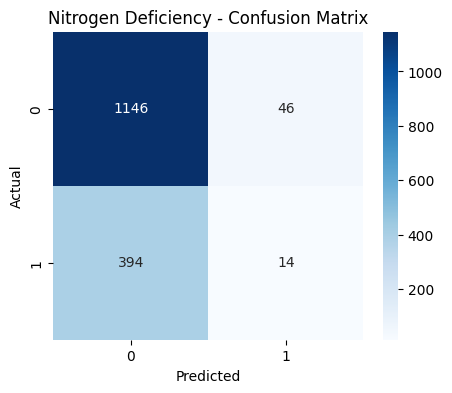

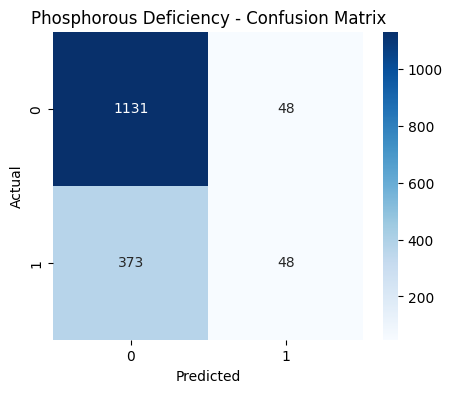

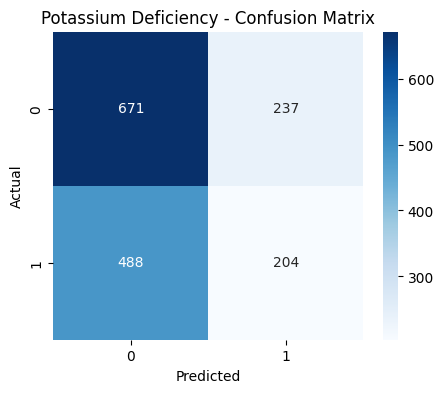

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrices
cm_N = confusion_matrix(y_test_N, pred_N_tuned)
cm_P = confusion_matrix(y_test_P, pred_P_tuned)
cm_K = confusion_matrix(y_test_K, pred_K_tuned)

# Nitrogen
plt.figure(figsize=(5,4))
sns.heatmap(cm_N, annot=True, fmt="d", cmap="Blues")
plt.title("Nitrogen Deficiency - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Phosphorous
plt.figure(figsize=(5,4))
sns.heatmap(cm_P, annot=True, fmt="d", cmap="Blues")
plt.title("Phosphorous Deficiency - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Potassium
plt.figure(figsize=(5,4))
sns.heatmap(cm_K, annot=True, fmt="d", cmap="Blues")
plt.title("Potassium Deficiency - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
import joblib

# Save the three tuned models
joblib.dump(best_model_N, "/content/best_xgb_nitrogen.pkl")
joblib.dump(best_model_P, "/content/best_xgb_phosphorous.pkl")
joblib.dump(best_model_K, "/content/best_xgb_potassium.pkl")

# Save the preprocessing pipeline
joblib.dump(preprocessor, "/content/soil_preprocessor.pkl")

print("All tuned XGBoost models and preprocessor saved successfully!")

All tuned XGBoost models and preprocessor saved successfully!


In [42]:
!pip install -q shap==0.52.0

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


Prepare the Nitrogen data for SHAP
Our encoded test data is stored as a sparse matrix, while SHAP needs a dense numerical array for this workflow. We will convert only the test data we need.

In [43]:


# Convert Nitrogen test data from sparse to dense format
X_test_N_shap = X_test_N.toarray().astype("float64")

# Get the encoded feature names
feature_names = preprocessor.get_feature_names_out()

print("SHAP data shape:", X_test_N_shap.shape)
print("Number of feature names:", len(feature_names))

SHAP data shape: (1600, 19)
Number of feature names: 19


In [44]:
# Create SHAP explainer for the tuned Nitrogen model
explainer_N = shap.TreeExplainer(best_model_N)

# Calculate SHAP values
shap_values_N = explainer_N.shap_values(X_test_N_shap)

print("Nitrogen SHAP values generated successfully!")
print("SHAP shape:", shap_values_N.shape)

Nitrogen SHAP values generated successfully!
SHAP shape: (1600, 19)


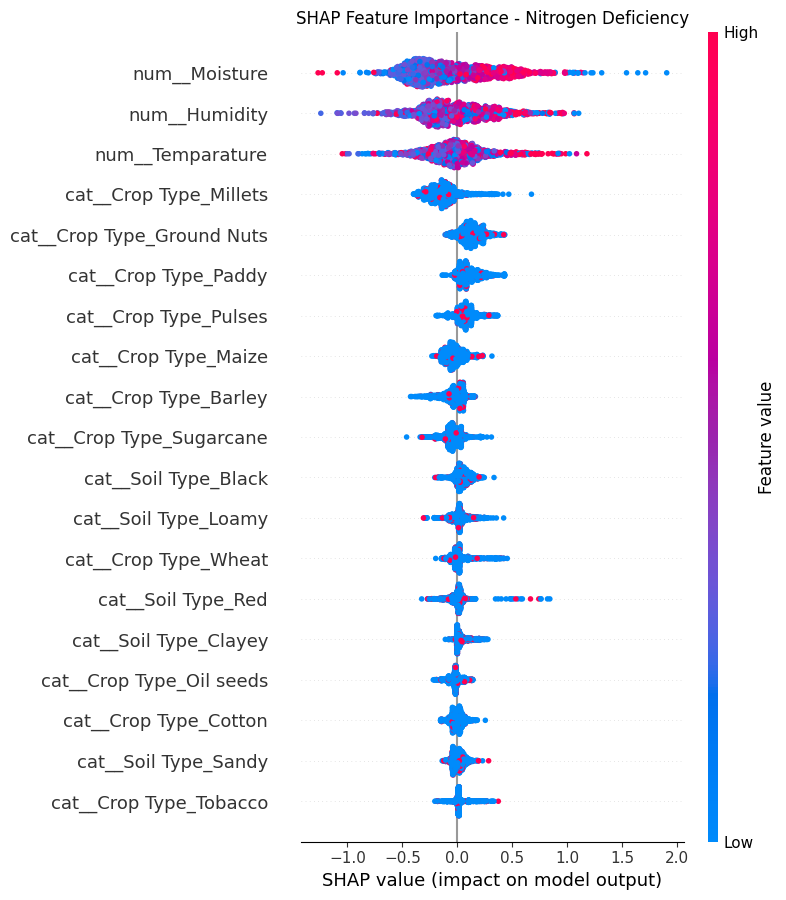

In [45]:
plt.figure()

shap.summary_plot(
    shap_values_N,
    X_test_N_shap,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance - Nitrogen Deficiency")
plt.tight_layout()
plt.show()

In [47]:
# Convert Phosphorous test data to dense format
X_test_P_shap = X_test_P.toarray().astype("float64")

print("SHAP data shape:", X_test_P_shap.shape)
print("Number of feature names:", len(feature_names))
# Create SHAP explainer for the tuned Phosphorous model
explainer_P = shap.TreeExplainer(best_model_P)

# Calculate SHAP values
shap_values_P = explainer_P.shap_values(X_test_P_shap)

print("Phosphorous SHAP values generated successfully!")
print("SHAP shape:", shap_values_P.shape)

SHAP data shape: (1600, 19)
Number of feature names: 19
Phosphorous SHAP values generated successfully!
SHAP shape: (1600, 19)


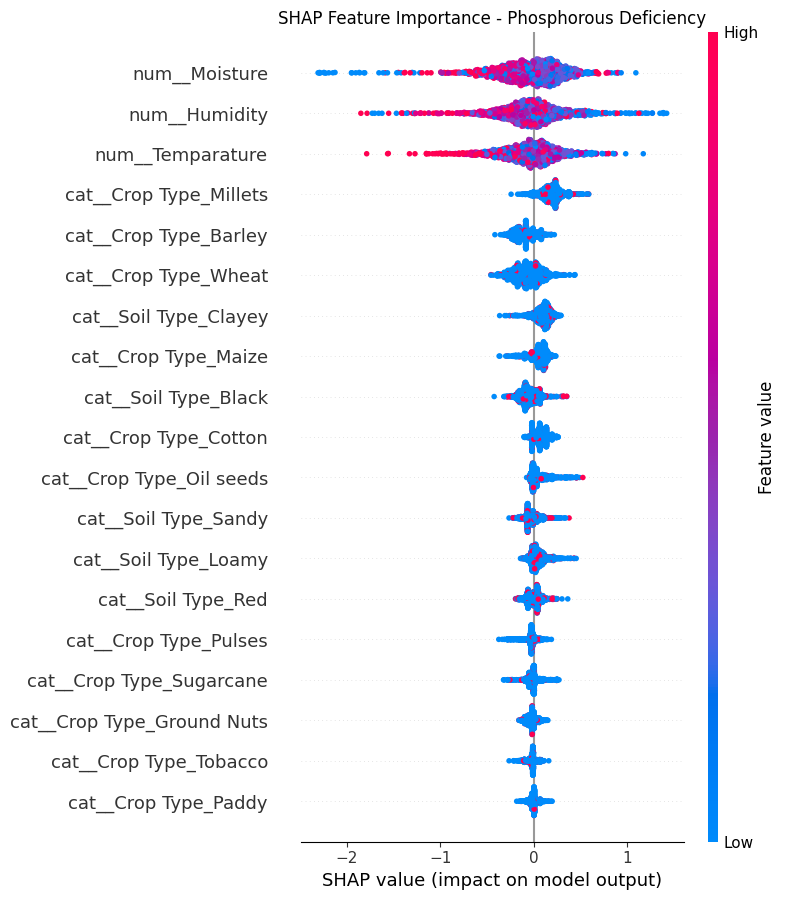

In [48]:
plt.figure()

shap.summary_plot(
    shap_values_P,
    X_test_P_shap,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance - Phosphorous Deficiency")
plt.tight_layout()
plt.show()

SHAP data shape: (1600, 19)
Number of feature names: 19
Potassium SHAP values generated successfully!
SHAP shape: (1600, 19)


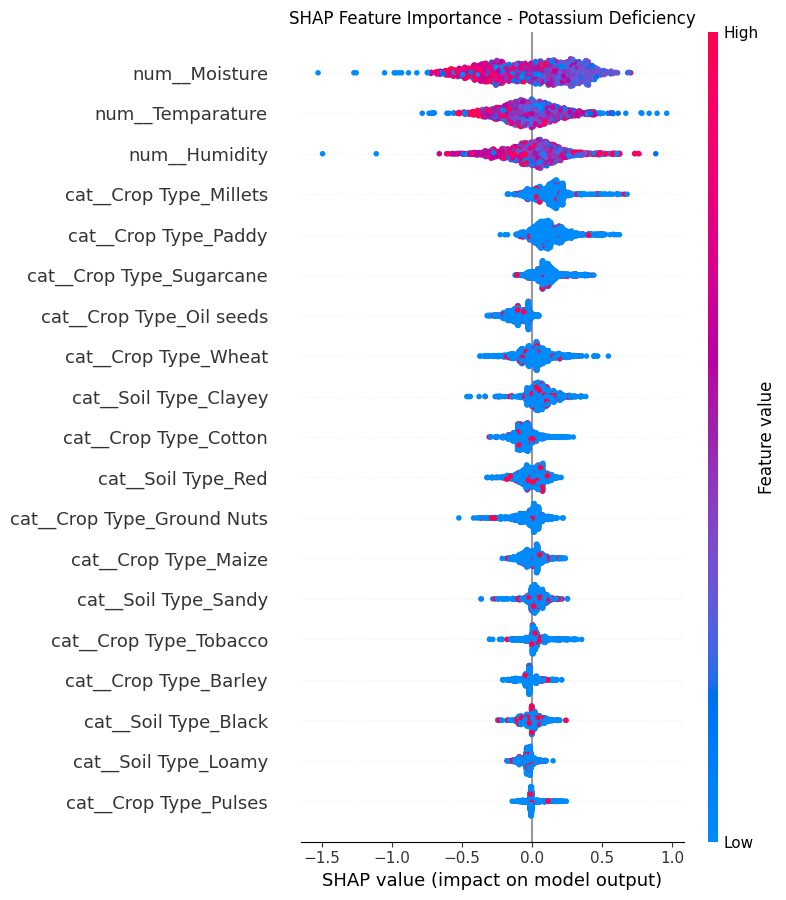

In [49]:
# ==========================================
# POTASSIUM SHAP ANALYSIS
# ==========================================

# 1. Convert test data from sparse to dense
X_test_K_shap = X_test_K.toarray().astype("float64")

print("SHAP data shape:", X_test_K_shap.shape)
print("Number of feature names:", len(feature_names))

# 2. Create SHAP explainer
explainer_K = shap.TreeExplainer(best_model_K)

# 3. Calculate SHAP values
shap_values_K = explainer_K.shap_values(X_test_K_shap)

print("Potassium SHAP values generated successfully!")
print("SHAP shape:", shap_values_K.shape)

# 4. Generate SHAP feature-importance plot
plt.figure()

shap.summary_plot(
    shap_values_K,
    X_test_K_shap,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance - Potassium Deficiency")
plt.tight_layout()
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import os

MODEL_PATH = "/content/drive/MyDrive/Soil_Project/soil_resnet50_model.keras"

print("Model exists:", os.path.exists(MODEL_PATH))

model = tf.keras.models.load_model(MODEL_PATH)

print("ResNet50 model loaded successfully!")

Model exists: True
ResNet50 model loaded successfully!


In [3]:
for layer in model.layers:
    print(layer.name, type(layer).__name__)

resnet50 Functional
global_average_pooling2d GlobalAveragePooling2D
dense Dense
dropout Dropout
dense_1 Dense


In [4]:
base_model = model.layers[0]

print("Base model:", base_model.name)
print("Number of layers:", len(base_model.layers))

for layer in base_model.layers[-20:]:
    print(layer.name, type(layer).__name__)

Base model: resnet50
Number of layers: 175
conv5_block2_1_conv Conv2D
conv5_block2_1_bn BatchNormalization
conv5_block2_1_relu Activation
conv5_block2_2_conv Conv2D
conv5_block2_2_bn BatchNormalization
conv5_block2_2_relu Activation
conv5_block2_3_conv Conv2D
conv5_block2_3_bn BatchNormalization
conv5_block2_add Add
conv5_block2_out Activation
conv5_block3_1_conv Conv2D
conv5_block3_1_bn BatchNormalization
conv5_block3_1_relu Activation
conv5_block3_2_conv Conv2D
conv5_block3_2_bn BatchNormalization
conv5_block3_2_relu Activation
conv5_block3_3_conv Conv2D
conv5_block3_3_bn BatchNormalization
conv5_block3_add Add
conv5_block3_out Activation


In [7]:
import tensorflow as tf

# Get the ResNet50 base model
base_model = model.layers[0]

# Get the last convolutional layer
last_conv_layer = base_model.get_layer("conv5_block3_3_conv")

# Create a model that outputs the last convolutional feature maps
conv_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=last_conv_layer.output
)

print("Convolution model created successfully!")
print("Target layer:", last_conv_layer.name)

Convolution model created successfully!
Target layer: conv5_block3_3_conv


In [8]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, predicted_class):
    # Watch the convolutional feature maps
    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_array, training=False)
        tape.watch(conv_outputs)

        # Pass feature maps through the remaining ResNet classifier
        x = model.layers[1](conv_outputs)

        for layer in model.layers[2:]:
            x = layer(x)

        class_output = x[:, predicted_class]

    # Gradients of the target class
    grads = tape.gradient(class_output, conv_outputs)

    # Average gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weight feature maps by gradients
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap /= max_value

    return heatmap.numpy()

print("Grad-CAM function created successfully!")

Grad-CAM function created successfully!


In [11]:
import zipfile
import os

ZIP_PATH = "/content/drive/MyDrive/Soil_Project/CyAUG-Dataset.zip"
EXTRACT_PATH = "/content/CyAUG-Dataset"

print("ZIP exists:", os.path.exists(ZIP_PATH))

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

DATASET_PATH = "/content/CyAUG-Dataset/CyAUG-Dataset"

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Classes:", sorted(os.listdir(DATASET_PATH)))

ZIP exists: True
Dataset exists: True
Classes: ['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False
)

class_names = list(val_generator.class_indices.keys())

print("Validation images:", val_generator.samples)
print("Classes:", class_names)

Found 1016 images belonging to 7 classes.
Validation images: 1016
Classes: ['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Get one batch of validation images
images, labels = next(val_generator)

# Predict classes
predictions = model.predict(images, verbose=0)

# Take the first image
img_array = images[0:1]

# Predicted class
predicted_class = np.argmax(predictions[0])

# Actual class
actual_class = np.argmax(labels[0])

# Generate Grad-CAM
heatmap = make_gradcam_heatmap(
    img_array,
    predicted_class
)

print("Actual class:", class_names[actual_class])
print("Predicted class:", class_names[predicted_class])
print("Heatmap shape:", heatmap.shape)

Actual class: Alluvial_Soil
Predicted class: Laterite_Soil
Heatmap shape: (7, 7)


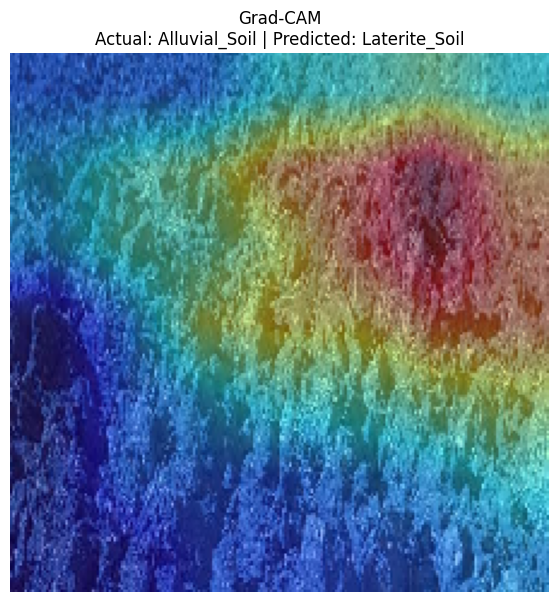

In [14]:
import cv2
import matplotlib.pyplot as plt

# Get original image
original_image = images[0]

# Convert from ResNet preprocessing back to displayable RGB
display_image = original_image.copy()

display_image = display_image - np.min(display_image)
display_image = display_image / np.max(display_image)
display_image = (display_image * 255).astype(np.uint8)

# Resize heatmap to image size
heatmap_resized = cv2.resize(
    heatmap,
    (display_image.shape[1], display_image.shape[0])
)

# Convert heatmap to color
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert BGR to RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay
overlay = cv2.addWeighted(
    display_image,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(7, 7))
plt.imshow(overlay)
plt.axis("off")
plt.title(
    f"Grad-CAM\nActual: {class_names[actual_class]} | "
    f"Predicted: {class_names[predicted_class]}"
)
plt.show()

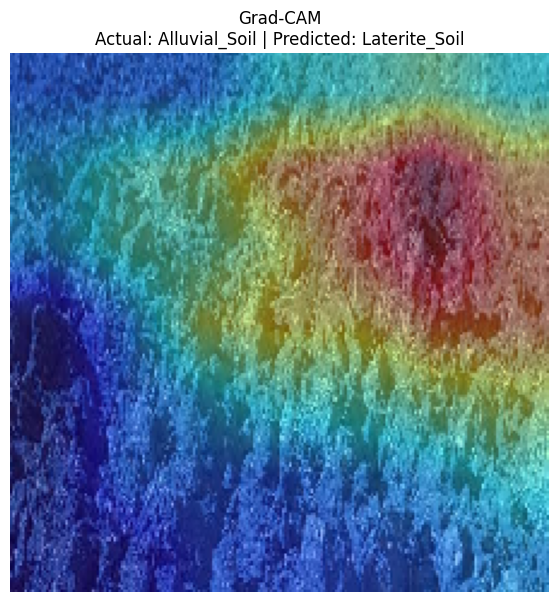

Grad-CAM saved successfully:
/content/drive/MyDrive/Soil_Project/GradCAM/GradCAM_Alluvial_to_Laterite.png


In [15]:
import os
from tensorflow.keras.preprocessing.image import array_to_img

GRADCAM_DIR = "/content/drive/MyDrive/Soil_Project/GradCAM"
os.makedirs(GRADCAM_DIR, exist_ok=True)

save_path = os.path.join(
    GRADCAM_DIR,
    "GradCAM_Alluvial_to_Laterite.png"
)

plt.figure(figsize=(7, 7))
plt.imshow(overlay)
plt.axis("off")
plt.title(
    f"Grad-CAM\nActual: {class_names[actual_class]} | "
    f"Predicted: {class_names[predicted_class]}"
)

plt.savefig(save_path, bbox_inches="tight", dpi=300)
plt.show()

print("Grad-CAM saved successfully:")
print(save_path)

In [16]:
# Find the first correctly predicted image
correct_index = None

for i in range(len(images)):
    actual = np.argmax(labels[i])
    predicted = np.argmax(predictions[i])

    if actual == predicted:
        correct_index = i
        break

print("Correct image index:", correct_index)
print("Actual:", class_names[np.argmax(labels[correct_index])])
print("Predicted:", class_names[np.argmax(predictions[correct_index])])

Correct image index: 2
Actual: Alluvial_Soil
Predicted: Alluvial_Soil


In [17]:
# Use the correct prediction we found
img_array_correct = images[correct_index:correct_index+1]

actual_correct = np.argmax(labels[correct_index])
predicted_correct = np.argmax(predictions[correct_index])

heatmap_correct = make_gradcam_heatmap(
    img_array_correct,
    predicted_correct
)

print("Actual:", class_names[actual_correct])
print("Predicted:", class_names[predicted_correct])
print("Heatmap shape:", heatmap_correct.shape)


Actual: Alluvial_Soil
Predicted: Alluvial_Soil
Heatmap shape: (7, 7)


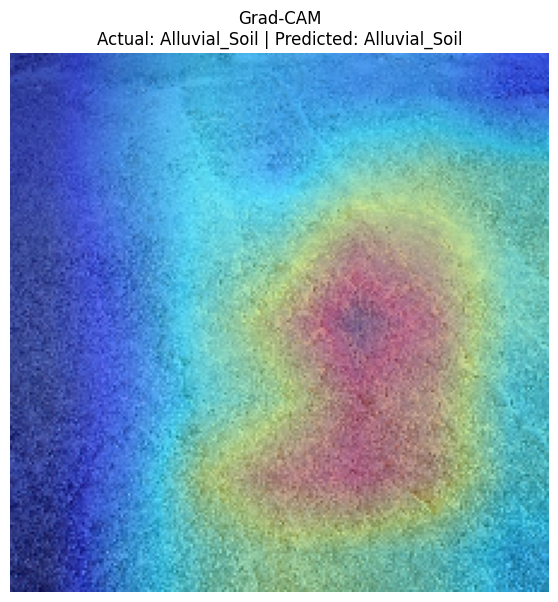

In [18]:
import cv2
import matplotlib.pyplot as plt

# Original image
original_correct = images[correct_index].copy()

# Convert for display
display_correct = original_correct - np.min(original_correct)
display_correct = display_correct / np.max(display_correct)
display_correct = (display_correct * 255).astype(np.uint8)

# Resize heatmap
heatmap_correct_resized = cv2.resize(
    heatmap_correct,
    (display_correct.shape[1], display_correct.shape[0])
)

# Convert heatmap to color
heatmap_correct_uint8 = np.uint8(255 * heatmap_correct_resized)

heatmap_correct_color = cv2.applyColorMap(
    heatmap_correct_uint8,
    cv2.COLORMAP_JET
)

heatmap_correct_color = cv2.cvtColor(
    heatmap_correct_color,
    cv2.COLOR_BGR2RGB
)

# Overlay
overlay_correct = cv2.addWeighted(
    display_correct,
    0.6,
    heatmap_correct_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(7,7))
plt.imshow(overlay_correct)
plt.axis("off")
plt.title(
    f"Grad-CAM\nActual: {class_names[actual_correct]} | "
    f"Predicted: {class_names[predicted_correct]}"
)
plt.show()


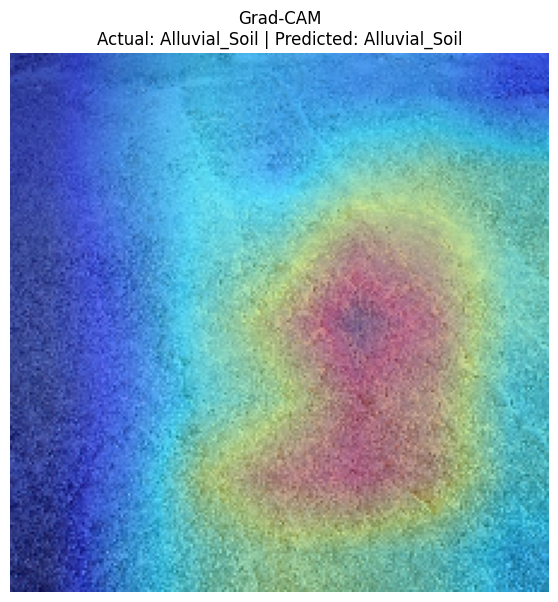

Saved successfully:
/content/drive/MyDrive/Soil_Project/GradCAM/GradCAM_Alluvial_Correct.png


In [19]:
GRADCAM_DIR = "/content/drive/MyDrive/Soil_Project/GradCAM"
os.makedirs(GRADCAM_DIR, exist_ok=True)

save_path_correct = os.path.join(
    GRADCAM_DIR,
    "GradCAM_Alluvial_Correct.png"
)

plt.figure(figsize=(7, 7))
plt.imshow(overlay_correct)
plt.axis("off")
plt.title(
    f"Grad-CAM\nActual: {class_names[actual_correct]} | "
    f"Predicted: {class_names[predicted_correct]}"
)

plt.savefig(save_path_correct, bbox_inches="tight", dpi=300)
plt.show()

print("Saved successfully:")
print(save_path_correct)

In [20]:
# Find the strongest attention region in each heatmap

def analyze_heatmap(heatmap):
    max_value = np.max(heatmap)
    max_position = np.unravel_index(
        np.argmax(heatmap),
        heatmap.shape
    )

    return max_value, max_position


# Incorrect prediction
max_incorrect, pos_incorrect = analyze_heatmap(heatmap)

# Correct prediction
max_correct, pos_correct = analyze_heatmap(heatmap_correct)

print("INCORRECT PREDICTION")
print("--------------------")
print("Actual:", class_names[actual_class])
print("Predicted:", class_names[predicted_class])
print("Strongest attention position:", pos_incorrect)
print("Maximum attention value:", round(float(max_incorrect), 4))

print("\nCORRECT PREDICTION")
print("------------------")
print("Actual:", class_names[actual_correct])
print("Predicted:", class_names[predicted_correct])
print("Strongest attention position:", pos_correct)
print("Maximum attention value:", round(float(max_correct), 4))

INCORRECT PREDICTION
--------------------
Actual: Alluvial_Soil
Predicted: Laterite_Soil
Strongest attention position: (np.int64(1), np.int64(5))
Maximum attention value: 1.0

CORRECT PREDICTION
------------------
Actual: Alluvial_Soil
Predicted: Alluvial_Soil
Strongest attention position: (np.int64(3), np.int64(4))
Maximum attention value: 1.0


Grad-CAM was used to visualize the regions of the soil images that influenced the ResNet50 classification decision. The visualization helps determine whether the model is focusing on meaningful soil texture and appearance rather than irrelevant regions.

In [24]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Saving data_core.csv to data_core.csv
Dataset loaded successfully!
Shape: (8000, 9)
Columns:
['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']


In [25]:
# Create deficiency thresholds from the dataset
N_threshold = df["Nitrogen"].quantile(0.25)
P_threshold = df["Phosphorous"].quantile(0.25)
K_threshold = df["Potassium"].quantile(0.25)

# Create deficiency labels
df["N_deficiency"] = (df["Nitrogen"] <= N_threshold).astype(int)
df["P_deficiency"] = (df["Phosphorous"] <= P_threshold).astype(int)
df["K_deficiency"] = (df["Potassium"] <= K_threshold).astype(int)

print("Deficiency thresholds:")
print("Nitrogen:", N_threshold)
print("Phosphorous:", P_threshold)
print("Potassium:", K_threshold)

print("\nDeficiency counts:")
print("Nitrogen:", df["N_deficiency"].value_counts().sort_index().to_dict())
print("Phosphorous:", df["P_deficiency"].value_counts().sort_index().to_dict())
print("Potassium:", df["K_deficiency"].value_counts().sort_index().to_dict())

Deficiency thresholds:
Nitrogen: 9.0
Phosphorous: 8.0
Potassium: 0.0

Deficiency counts:
Nitrogen: {0: 5961, 1: 2039}
Phosphorous: {0: 5894, 1: 2106}
Potassium: {0: 4540, 1: 3460}


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Features — exclude N, P, K to prevent target leakage
X = df[
    ["Temparature", "Humidity", "Moisture", "Soil Type", "Crop Type"]
]

# Targets
y_N = df["N_deficiency"]
y_P = df["P_deficiency"]
y_K = df["K_deficiency"]

# Feature types
numeric_features = [
    "Temparature",
    "Humidity",
    "Moisture"
]

categorical_features = [
    "Soil Type",
    "Crop Type"
]

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Transform features
X_encoded = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)


Original shape: (8000, 5)
Encoded shape: (8000, 19)


In [27]:
from sklearn.model_selection import train_test_split

X_train_N, X_test_N, y_train_N, y_test_N = train_test_split(
    X_encoded, y_N,
    test_size=0.20,
    random_state=42,
    stratify=y_N
)

X_train_P, X_test_P, y_train_P, y_test_P = train_test_split(
    X_encoded, y_P,
    test_size=0.20,
    random_state=42,
    stratify=y_P
)

X_train_K, X_test_K, y_train_K, y_test_K = train_test_split(
    X_encoded, y_K,
    test_size=0.20,
    random_state=42,
    stratify=y_K
)

print("Nitrogen:", X_train_N.shape, X_test_N.shape)
print("Phosphorous:", X_train_P.shape, X_test_P.shape)
print("Potassium:", X_train_K.shape, X_test_K.shape)

Nitrogen: (6400, 19) (1600, 19)
Phosphorous: (6400, 19) (1600, 19)
Potassium: (6400, 19) (1600, 19)


In [28]:
from xgboost import XGBClassifier

# Nitrogen model
model_N = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

# Phosphorous model
model_P = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

# Potassium model
model_K = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

# Train
model_N.fit(X_train_N, y_train_N)
model_P.fit(X_train_P, y_train_P)
model_K.fit(X_train_K, y_train_K)

print("All three XGBoost models trained successfully!")

All three XGBoost models trained successfully!


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = [
    ("Nitrogen", model_N, X_test_N, y_test_N),
    ("Phosphorous", model_P, X_test_P, y_test_P),
    ("Potassium", model_K, X_test_K, y_test_K)
]

for name, model, X_test, y_test in models:
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
    print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
    print("F1-score :", round(f1_score(y_test, y_pred, zero_division=0), 4))


Nitrogen
Accuracy : 0.725
Precision: 0.2333
Recall   : 0.0343
F1-score : 0.0598

Phosphorous
Accuracy : 0.7369
Precision: 0.5
Recall   : 0.114
F1-score : 0.1857

Potassium
Accuracy : 0.5469
Precision: 0.4626
Recall   : 0.2948
F1-score : 0.3601


In [30]:
import joblib
import os

MODEL_DIR = "/content/drive/MyDrive/Soil_Project"

# Save the three trained XGBoost models
joblib.dump(
    model_N,
    os.path.join(MODEL_DIR, "best_xgb_nitrogen.pkl")
)

joblib.dump(
    model_P,
    os.path.join(MODEL_DIR, "best_xgb_phosphorous.pkl")
)

joblib.dump(
    model_K,
    os.path.join(MODEL_DIR, "best_xgb_potassium.pkl")
)

# Save the preprocessing pipeline
joblib.dump(
    preprocessor,
    os.path.join(MODEL_DIR, "soil_preprocessor.pkl")
)

print("All Week 4 models saved permanently to Drive!")

print("\nSaved files:")
for filename in [
    "best_xgb_nitrogen.pkl",
    "best_xgb_phosphorous.pkl",
    "best_xgb_potassium.pkl",
    "soil_preprocessor.pkl"
]:
    path = os.path.join(MODEL_DIR, filename)
    print(filename, "->", os.path.exists(path))

All Week 4 models saved permanently to Drive!

Saved files:
best_xgb_nitrogen.pkl -> True
best_xgb_phosphorous.pkl -> True
best_xgb_potassium.pkl -> True
soil_preprocessor.pkl -> True


In [31]:
import numpy as np

def predict_npk_deficiency(
    temperature,
    humidity,
    moisture,
    soil_type,
    crop_type
):
    # Create one input row
    input_data = pd.DataFrame([{
        "Temparature": temperature,
        "Humidity": humidity,
        "Moisture": moisture,
        "Soil Type": soil_type,
        "Crop Type": crop_type
    }])

    # Apply the same preprocessing used during training
    input_encoded = preprocessor.transform(input_data)

    # Predict deficiency
    n_pred = model_N.predict(input_encoded)[0]
    p_pred = model_P.predict(input_encoded)[0]
    k_pred = model_K.predict(input_encoded)[0]

    # Prediction probabilities
    n_prob = model_N.predict_proba(input_encoded)[0][1]
    p_prob = model_P.predict_proba(input_encoded)[0][1]
    k_prob = model_K.predict_proba(input_encoded)[0][1]

    return {
        "Nitrogen_deficient": int(n_pred),
        "Phosphorous_deficient": int(p_pred),
        "Potassium_deficient": int(k_pred),
        "Nitrogen_probability": float(n_prob),
        "Phosphorous_probability": float(p_prob),
        "Potassium_probability": float(k_prob)
    }

print("Hybrid structured-data prediction function created!")

Hybrid structured-data prediction function created!


In [32]:
sample = df.iloc[0]

result = predict_npk_deficiency(
    temperature=sample["Temparature"],
    humidity=sample["Humidity"],
    moisture=sample["Moisture"],
    soil_type=sample["Soil Type"],
    crop_type=sample["Crop Type"]
)

print("Input sample:")
print("Temperature:", sample["Temparature"])
print("Humidity:", sample["Humidity"])
print("Moisture:", sample["Moisture"])
print("Soil Type:", sample["Soil Type"])
print("Crop Type:", sample["Crop Type"])

print("\nStructured-data predictions:")
print(result)

Input sample:
Temperature: 26.0
Humidity: 52.0
Moisture: 38.0
Soil Type: Sandy
Crop Type: Maize

Structured-data predictions:
{'Nitrogen_deficient': 0, 'Phosphorous_deficient': 0, 'Potassium_deficient': 1, 'Nitrogen_probability': 0.13038843870162964, 'Phosphorous_probability': 0.2836593687534332, 'Potassium_probability': 0.5260996222496033}


In [33]:
#image model confidence
# Use the image from our Grad-CAM analysis
image_prediction = predictions[0]

image_class_index = np.argmax(image_prediction)
image_class = class_names[image_class_index]
image_confidence = float(image_prediction[image_class_index])

print("Image model prediction:", image_class)
print("Image model confidence:", round(image_confidence * 100, 2), "%")

Image model prediction: Laterite_Soil
Image model confidence: 62.57 %


In [34]:
def create_hybrid_assessment(
    soil_class,
    image_confidence,
    structured_result
):
    # Nutrient probabilities
    n_prob = structured_result["Nitrogen_probability"]
    p_prob = structured_result["Phosphorous_probability"]
    k_prob = structured_result["Potassium_probability"]

    # Deficiency predictions
    deficiencies = []

    if structured_result["Nitrogen_deficient"] == 1:
        deficiencies.append("Nitrogen")

    if structured_result["Phosphorous_deficient"] == 1:
        deficiencies.append("Phosphorous")

    if structured_result["Potassium_deficient"] == 1:
        deficiencies.append("Potassium")

    # Simple project-level health score
    health_score = 100

    for nutrient in deficiencies:
        health_score -= 15

    # Overall status
    if health_score >= 80:
        health_status = "Good"
    elif health_score >= 60:
        health_status = "Moderate"
    else:
        health_status = "Needs Attention"

    return {
        "Predicted Soil Type": soil_class,
        "Image Confidence (%)": round(image_confidence * 100, 2),
        "Nitrogen Probability (%)": round(n_prob * 100, 2),
        "Phosphorous Probability (%)": round(p_prob * 100, 2),
        "Potassium Probability (%)": round(k_prob * 100, 2),
        "Predicted Deficiencies": deficiencies,
        "Soil Health Score": health_score,
        "Soil Health Status": health_status
    }


hybrid_result = create_hybrid_assessment(
    image_class,
    image_confidence,
    result
)

print("HYBRID SOIL ASSESSMENT")
print("----------------------")

for key, value in hybrid_result.items():
    print(f"{key}: {value}")

HYBRID SOIL ASSESSMENT
----------------------
Predicted Soil Type: Laterite_Soil
Image Confidence (%): 62.57
Nitrogen Probability (%): 13.04
Phosphorous Probability (%): 28.37
Potassium Probability (%): 52.61
Predicted Deficiencies: ['Potassium']
Soil Health Score: 85
Soil Health Status: Good


In [35]:
def confidence_level(confidence):
    if confidence >= 0.80:
        return "High"
    elif confidence >= 0.60:
        return "Medium"
    else:
        return "Low"


# Image confidence
image_confidence_level = confidence_level(image_confidence)

# Nutrient confidence
n_confidence = confidence_level(result["Nitrogen_probability"])
p_confidence = confidence_level(result["Phosphorous_probability"])
k_confidence = confidence_level(result["Potassium_probability"])

print("CONFIDENCE-SCORE HANDLING")
print("-------------------------")
print("Soil classification:", image_confidence_level)
print("Nitrogen deficiency:", n_confidence)
print("Phosphorous deficiency:", p_confidence)
print("Potassium deficiency:", k_confidence)

CONFIDENCE-SCORE HANDLING
-------------------------
Soil classification: Medium
Nitrogen deficiency: Low
Phosphorous deficiency: Low
Potassium deficiency: Low


In [36]:
def generate_advisory(hybrid_result, image_confidence, structured_result):

    advisory = []

    # Soil classification confidence
    if image_confidence < 0.60:
        advisory.append(
            "Soil classification confidence is low. "
            "Consider obtaining another soil image."
        )
    elif image_confidence < 0.80:
        advisory.append(
            "Soil classification confidence is moderate."
        )
    else:
        advisory.append(
            "Soil classification confidence is high."
        )

    # Nutrient recommendations
    if structured_result["Nitrogen_deficient"] == 1:
        advisory.append(
            "Nitrogen deficiency is predicted. "
            "Consider nitrogen-rich soil management."
        )

    if structured_result["Phosphorous_deficient"] == 1:
        advisory.append(
            "Phosphorous deficiency is predicted. "
            "Consider phosphorous supplementation."
        )

    if structured_result["Potassium_deficient"] == 1:
        advisory.append(
            "Potassium deficiency is predicted. "
            "Consider potassium supplementation, subject to soil-test verification."
        )

    if len(advisory) == 1:
        advisory.append(
            "No nutrient deficiency was strongly predicted."
        )

    return advisory


advisory = generate_advisory(
    hybrid_result,
    image_confidence,
    result
)

print("FINAL HYBRID ADVISORY")
print("---------------------")

for i, message in enumerate(advisory, 1):
    print(f"{i}. {message}")

FINAL HYBRID ADVISORY
---------------------
1. Soil classification confidence is moderate.
2. Potassium deficiency is predicted. Consider potassium supplementation, subject to soil-test verification.


In [37]:
#multiple tests on hybrid model
# Test hybrid system on 5 different structured-data samples

test_indices = [0, 100, 500, 1000, 2000]

for idx in test_indices:

    sample = df.iloc[idx]

    structured_result = predict_npk_deficiency(
        temperature=sample["Temparature"],
        humidity=sample["Humidity"],
        moisture=sample["Moisture"],
        soil_type=sample["Soil Type"],
        crop_type=sample["Crop Type"]
    )

    print("\n" + "="*50)
    print("Sample:", idx)
    print("Soil Type:", sample["Soil Type"])
    print("Crop Type:", sample["Crop Type"])

    print("\nNutrient predictions:")
    print("Nitrogen:", structured_result["Nitrogen_deficient"],
          "| Probability:",
          round(structured_result["Nitrogen_probability"] * 100, 2), "%")

    print("Phosphorous:", structured_result["Phosphorous_deficient"],
          "| Probability:",
          round(structured_result["Phosphorous_probability"] * 100, 2), "%")

    print("Potassium:", structured_result["Potassium_deficient"],
          "| Probability:",
          round(structured_result["Potassium_probability"] * 100, 2), "%")


Sample: 0
Soil Type: Sandy
Crop Type: Maize

Nutrient predictions:
Nitrogen: 0 | Probability: 13.04 %
Phosphorous: 0 | Probability: 28.37 %
Potassium: 1 | Probability: 52.61 %

Sample: 100
Soil Type: Black
Crop Type: Millets

Nutrient predictions:
Nitrogen: 0 | Probability: 25.33 %
Phosphorous: 0 | Probability: 6.13 %
Potassium: 0 | Probability: 33.44 %

Sample: 500
Soil Type: Black
Crop Type: Ground Nuts

Nutrient predictions:
Nitrogen: 0 | Probability: 26.45 %
Phosphorous: 0 | Probability: 20.8 %
Potassium: 0 | Probability: 36.25 %

Sample: 1000
Soil Type: Sandy
Crop Type: Sugarcane

Nutrient predictions:
Nitrogen: 0 | Probability: 32.12 %
Phosphorous: 0 | Probability: 18.21 %
Potassium: 0 | Probability: 32.08 %

Sample: 2000
Soil Type: Red
Crop Type: Sugarcane

Nutrient predictions:
Nitrogen: 1 | Probability: 81.6 %
Phosphorous: 0 | Probability: 0.52 %
Potassium: 0 | Probability: 10.48 %


In [38]:
hybrid_rows = []

for idx in test_indices:

    sample = df.iloc[idx]

    structured_result = predict_npk_deficiency(
        temperature=sample["Temparature"],
        humidity=sample["Humidity"],
        moisture=sample["Moisture"],
        soil_type=sample["Soil Type"],
        crop_type=sample["Crop Type"]
    )

    hybrid_rows.append({
        "Sample": idx,
        "Soil Type": sample["Soil Type"],
        "Crop Type": sample["Crop Type"],
        "N Deficient": structured_result["Nitrogen_deficient"],
        "N Probability (%)": round(
            structured_result["Nitrogen_probability"] * 100, 2
        ),
        "P Deficient": structured_result["Phosphorous_deficient"],
        "P Probability (%)": round(
            structured_result["Phosphorous_probability"] * 100, 2
        ),
        "K Deficient": structured_result["Potassium_deficient"],
        "K Probability (%)": round(
            structured_result["Potassium_probability"] * 100, 2
        )
    })

hybrid_df = pd.DataFrame(hybrid_rows)

HYBRID_PATH = (
    "/content/drive/MyDrive/Soil_Project/"
    "Hybrid_Test_Results.csv"
)

hybrid_df.to_csv(HYBRID_PATH, index=False)

print("Hybrid test results:")
display(hybrid_df)

print("\nSaved successfully:")
print(HYBRID_PATH)

Hybrid test results:


,Sample,Soil Type,Crop Type,N Deficient,N Probability (%),P Deficient,P Probability (%),K Deficient,K Probability (%)
0,0,Sandy,Maize,0,13.04,0,28.37,1,52.61
1,100,Black,Millets,0,25.33,0,6.13,0,33.44
2,500,Black,Ground Nuts,0,26.45,0,20.80,0,36.25
3,1000,Sandy,Sugarcane,0,32.12,0,18.21,0,32.08
4,2000,Red,Sugarcane,1,81.60,0,0.52,0,10.48



Saved successfully:
/content/drive/MyDrive/Soil_Project/Hybrid_Test_Results.csv


In [39]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Soil_Project"

required_files = [
    "CyAUG-Dataset.zip",
    "soil_resnet50_model.keras",
    "best_soil_resnet50.keras",
    "ResNet50_classification_report.csv",
    "ResNet50_confusion_matrix.csv",
    "best_xgb_nitrogen.pkl",
    "best_xgb_phosphorous.pkl",
    "best_xgb_potassium.pkl",
    "soil_preprocessor.pkl",
    "Hybrid_Test_Results.csv"
]

print("FINAL MILESTONE 2 FILE CHECK")
print("=" * 40)

for filename in required_files:
    path = os.path.join(PROJECT_DIR, filename)
    status = "✓ FOUND" if os.path.exists(path) else "✗ MISSING"
    print(f"{status}: {filename}")

FINAL MILESTONE 2 FILE CHECK
✓ FOUND: CyAUG-Dataset.zip
✓ FOUND: soil_resnet50_model.keras
✓ FOUND: best_soil_resnet50.keras
✓ FOUND: ResNet50_classification_report.csv
✓ FOUND: ResNet50_confusion_matrix.csv
✓ FOUND: best_xgb_nitrogen.pkl
✓ FOUND: best_xgb_phosphorous.pkl
✓ FOUND: best_xgb_potassium.pkl
✓ FOUND: soil_preprocessor.pkl
✓ FOUND: Hybrid_Test_Results.csv
